# AlphaFold Uncertainty vs. Model Error

Does model prediction error correlate with AlphaFold's own structural
confidence (pLDDT, PAE) near a query node? And separately -- is error
better explained by how locally *unstable* the ground-truth ESP field
itself is at that location, independent of AF confidence? If so, "hard to
predict" is sometimes a property of the physics, not a model or
structure-quality failure.

Data comes entirely from `scripts/compute_confidence_error_stats.py`'s
cached outputs -- this notebook never re-runs inference or recomputes the
pLDDT/PAE/local-ESP join; it only loads and visualizes. Both full-dataset
champion checkpoints (`attention_aa4_aq2_qq16`, `distance_aa8_aq2_qq24`,
migrated 2026-09-18 to the slim graph format --
`checkpoints/full_dataset_slim/`, see THESISPROCESSES.md "Graph Storage --
Slim Edge Attributes") are covered, using their existing cached test-split
predictions.

**Methodology**: each query mesh vertex is mapped to its nearest atom
(`cKDTree`), then that atom's PQR residue number gives AlphaFold's
per-residue pLDDT (`metadata.json::plddt_per_residue`) and mean PAE
(row-mean of the residue's predicted-aligned-error to every other
residue). "Local ESP volatility" (`local_esp_std`) and "local ESP
gradient" (`local_esp_grad`) are computed from the k=16 nearest mesh
vertices' *ground-truth* ESP values only -- a property of the physical
field, not of any prediction.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path("..").resolve()))

MODELS = ["attention", "distance"]
MODEL_COLORS = {"attention": "steelblue", "distance": "darkorange"}
PLDDT_BAND_ORDER = ["very_low", "low", "confident", "very_high"]
PLDDT_BAND_LABELS = {"very_low": "<50\n(very low)", "low": "50-70\n(low)",
                      "confident": "70-90\n(confident)", "very_high": "90+\n(very high)"}

---
## 1. Load Cached Outputs

In [2]:
dataset = pd.read_csv("/home/student/thesis/outputs/confidence_error_dataset.csv.gz")
buckets = pd.read_csv("/home/student/thesis/outputs/confidence_error_buckets.csv")
protein_summary = pd.read_csv("/home/student/thesis/outputs/confidence_error_protein_summary.csv")

print(f"dataset: {len(dataset):,} query-vertex rows")
print(f"proteins covered: {dataset['protein_id'].nunique()}")
print(f"PAE coverage: {protein_summary['has_pae'].mean():.1%} of proteins")
print(f"total out-of-range query nodes dropped: {protein_summary['n_out_of_range'].sum():,} "
      f"(of {protein_summary['n_query'].sum():,} total)")
dataset.head()

dataset: 5,764,920 query-vertex rows
proteins covered: 848
PAE coverage: 100.0% of proteins
total out-of-range query nodes dropped: 0 (of 5,764,920 total)


,protein_id,model,resid,plddt,pae_mean,local_esp_std,local_esp_grad,true_esp,abs_error
0,AF-A0A023PXF5-F1,attention,89,38.000000,22.847618,0.910384,0.797444,5.112916,0.438331
1,AF-A0A023PXF5-F1,attention,89,38.000000,22.847618,0.379592,0.403842,2.221341,0.284266
2,AF-A0A023PXF5-F1,attention,86,53.880001,20.247620,0.334048,0.255565,2.647883,0.046034
3,AF-A0A023PXF5-F1,attention,97,30.480000,19.828571,0.344406,0.416988,4.573432,0.865026
4,AF-A0A023PXF5-F1,attention,97,30.480000,19.828571,0.165326,0.195513,1.517825,0.450312


---
## 2. pLDDT vs. Model Error

AlphaFold's own confidence bands: very low (<50), low (50-70), confident
(70-90), very high (90+). If low-confidence AF regions are also
high-error regions, that suggests the model inherits structural
uncertainty from the input, not just its own weaknesses.

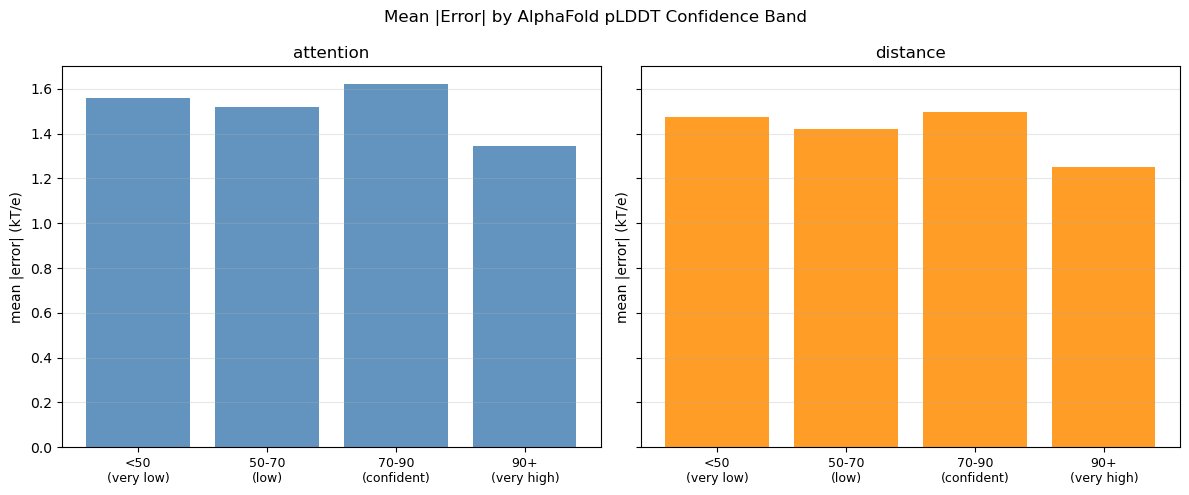

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, model in zip(axes, MODELS):
    sub = buckets[(buckets["model"] == model) & (buckets["predictor"] == "plddt_band")]
    sub = sub.set_index("bin").reindex(PLDDT_BAND_ORDER).reset_index()
    x = np.arange(len(sub))
    ax.bar(x, sub["mean_abs_error"], color=MODEL_COLORS[model], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([PLDDT_BAND_LABELS[b] for b in sub["bin"]], fontsize=9)
    ax.set_title(f"{model}")
    ax.set_ylabel("mean |error| (kT/e)")
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("Mean |Error| by AlphaFold pLDDT Confidence Band")
plt.tight_layout()
plt.show()

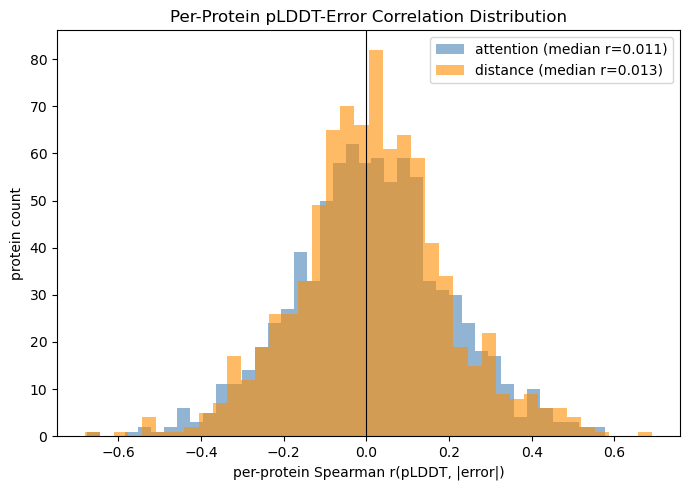

attention: pooled Spearman r(plddt, abs_error) = -0.0941 (p=0.00e+00, n=2,882,460)


distance: pooled Spearman r(plddt, abs_error) = -0.1009 (p=0.00e+00, n=2,882,460)


In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
for model in MODELS:
    r = protein_summary.loc[protein_summary["model"] == model, "spearman_plddt_error"].dropna()
    ax.hist(r, bins=40, alpha=0.6, label=f"{model} (median r={r.median():.3f})",
            color=MODEL_COLORS[model])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("per-protein Spearman r(pLDDT, |error|)")
ax.set_ylabel("protein count")
ax.set_title("Per-Protein pLDDT-Error Correlation Distribution")
ax.legend()
plt.tight_layout()
plt.show()

for model in MODELS:
    r_pooled = spearmanr(dataset.loc[dataset.model == model, "plddt"],
                          dataset.loc[dataset.model == model, "abs_error"])
    print(f"{model}: pooled Spearman r(plddt, abs_error) = {r_pooled.correlation:.4f} "
          f"(p={r_pooled.pvalue:.2e}, n={ (dataset.model == model).sum():,})")

---
## 3. PAE vs. Model Error

PAE (Predicted Aligned Error) is AlphaFold's *pairwise* residue-position
confidence; here summarized per residue as its mean PAE to every other
residue. Coverage is reported above since PAE download can fail per
protein -- not assumed complete.

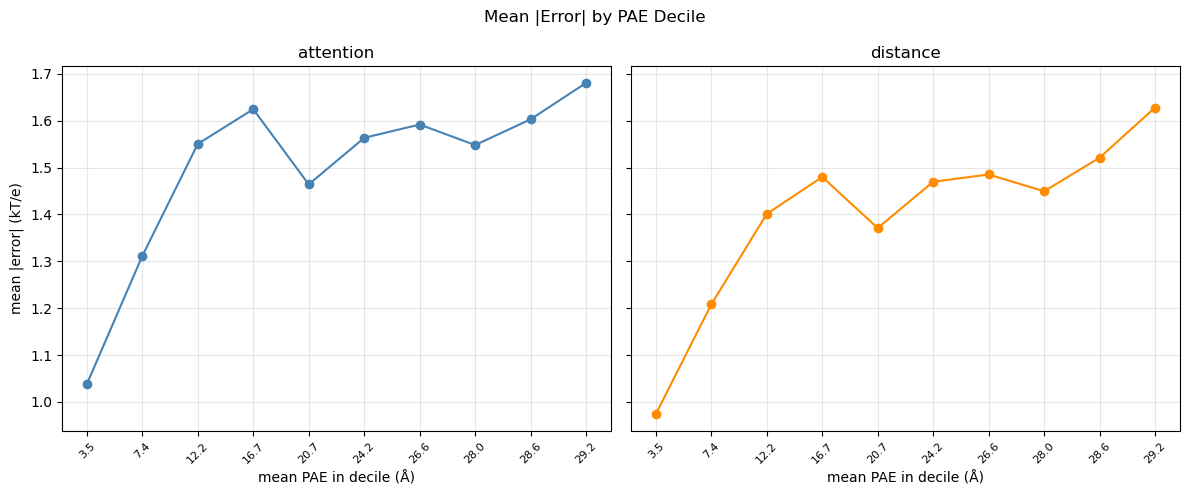

attention: pooled Spearman r(pae_mean, abs_error) = 0.1204 (p=0.00e+00, n=2,882,460)


distance: pooled Spearman r(pae_mean, abs_error) = 0.1338 (p=0.00e+00, n=2,882,460)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, model in zip(axes, MODELS):
    sub = buckets[(buckets["model"] == model) & (buckets["predictor"] == "pae_mean_decile")]
    x = np.arange(len(sub))
    ax.plot(x, sub["mean_abs_error"], "o-", color=MODEL_COLORS[model])
    ax.set_xticks(x)
    ax.set_xticklabels([f"{v:.1f}" for v in sub["mean_value"]], rotation=45, fontsize=8)
    ax.set_xlabel("mean PAE in decile (\u00c5)")
    ax.set_title(model)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("mean |error| (kT/e)")
plt.suptitle("Mean |Error| by PAE Decile")
plt.tight_layout()
plt.show()

for model in MODELS:
    sub = dataset[(dataset.model == model) & dataset["pae_mean"].notna()]
    r_pooled = spearmanr(sub["pae_mean"], sub["abs_error"])
    print(f"{model}: pooled Spearman r(pae_mean, abs_error) = {r_pooled.correlation:.4f} "
          f"(p={r_pooled.pvalue:.2e}, n={len(sub):,})")

---
## 4. Local ESP Volatility/Gradient vs. Model Error

The central question: is error better explained by how *physically
unstable* the ESP field is right at that point, independent of AlphaFold
structural confidence? `local_esp_std` is the ESP standard deviation
among each query node's 16 nearest mesh-vertex neighbors (ground truth
only); `local_esp_grad` is the mean local gradient magnitude.

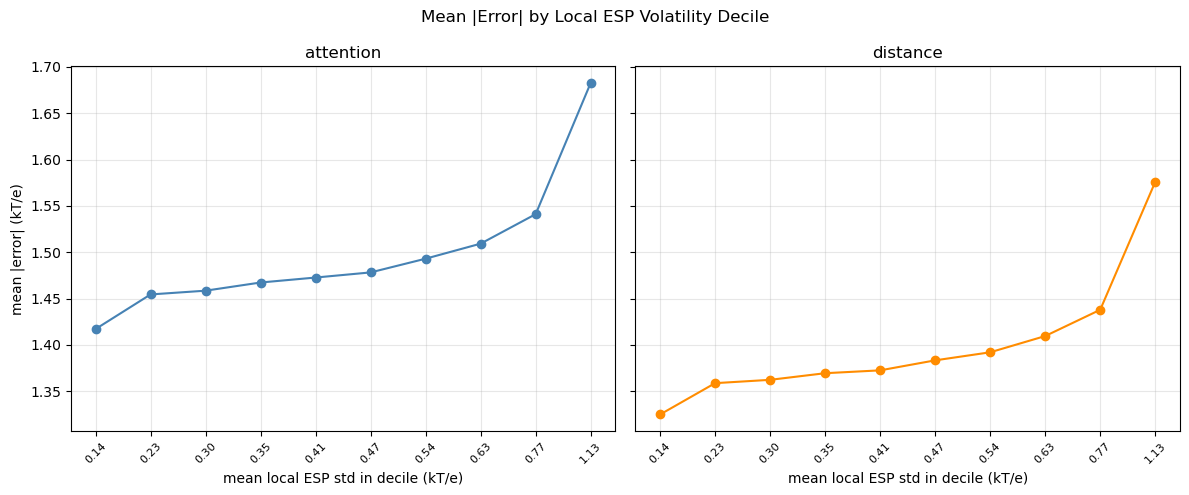

attention: pooled Spearman r(local_esp_std, abs_error) = 0.0375 (p=0.00e+00)
attention: pooled Spearman r(local_esp_grad, abs_error) = 0.0453 (p=0.00e+00)


distance: pooled Spearman r(local_esp_std, abs_error) = 0.0383 (p=0.00e+00)
distance: pooled Spearman r(local_esp_grad, abs_error) = 0.0463 (p=0.00e+00)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, model in zip(axes, MODELS):
    sub = buckets[(buckets["model"] == model) & (buckets["predictor"] == "local_esp_std_decile")]
    x = np.arange(len(sub))
    ax.plot(x, sub["mean_abs_error"], "o-", color=MODEL_COLORS[model])
    ax.set_xticks(x)
    ax.set_xticklabels([f"{v:.2f}" for v in sub["mean_value"]], rotation=45, fontsize=8)
    ax.set_xlabel("mean local ESP std in decile (kT/e)")
    ax.set_title(model)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("mean |error| (kT/e)")
plt.suptitle("Mean |Error| by Local ESP Volatility Decile")
plt.tight_layout()
plt.show()

for model in MODELS:
    sub = dataset[dataset.model == model]
    r_std = spearmanr(sub["local_esp_std"], sub["abs_error"])
    r_grad = spearmanr(sub["local_esp_grad"], sub["abs_error"])
    print(f"{model}: pooled Spearman r(local_esp_std, abs_error) = {r_std.correlation:.4f} (p={r_std.pvalue:.2e})")
    print(f"{model}: pooled Spearman r(local_esp_grad, abs_error) = {r_grad.correlation:.4f} (p={r_grad.pvalue:.2e})")

### Does local ESP volatility explain error *independent of* pLDDT?

Two-predictor linear regression of `abs_error` on standardized `plddt`
and `local_esp_std` per model -- standardized coefficients are directly
comparable, and R² is reported for each predictor alone vs. combined to
show whether they carry overlapping or independent signal.

In [7]:
for model in MODELS:
    sub = dataset[dataset.model == model].dropna(subset=["plddt", "local_esp_std", "abs_error"])
    y = sub["abs_error"].to_numpy()

    scaler = StandardScaler()
    X_plddt = scaler.fit_transform(sub[["plddt"]])
    X_local = scaler.fit_transform(sub[["local_esp_std"]])
    X_both = np.hstack([X_plddt, X_local])

    r2_plddt = r2_score(y, LinearRegression().fit(X_plddt, y).predict(X_plddt))
    r2_local = r2_score(y, LinearRegression().fit(X_local, y).predict(X_local))
    combined = LinearRegression().fit(X_both, y)
    r2_combined = r2_score(y, combined.predict(X_both))

    print(f"=== {model} ===")
    print(f"  R\u00b2(plddt alone)              = {r2_plddt:.4f}")
    print(f"  R\u00b2(local_esp_std alone)      = {r2_local:.4f}")
    print(f"  R\u00b2(both combined)            = {r2_combined:.4f}")
    print(f"  standardized coefficients: plddt={combined.coef_[0]:+.4f}  local_esp_std={combined.coef_[1]:+.4f}")
    print()

=== attention ===
  R²(plddt alone)              = 0.0030
  R²(local_esp_std alone)      = 0.0047
  R²(both combined)            = 0.0086
  standardized coefficients: plddt=-0.0867  local_esp_std=+0.1041



=== distance ===
  R²(plddt alone)              = 0.0040
  R²(local_esp_std alone)      = 0.0049
  R²(both combined)            = 0.0100
  standardized coefficients: plddt=-0.0934  local_esp_std=+0.1005



---
## 5. Do Low Confidence and High Volatility Compound?

2D heatmap of mean |error| over a (pLDDT band × local-ESP-volatility
decile) grid. If the two effects are independent and additive, the worst
cell should be low-pLDDT × high-volatility.

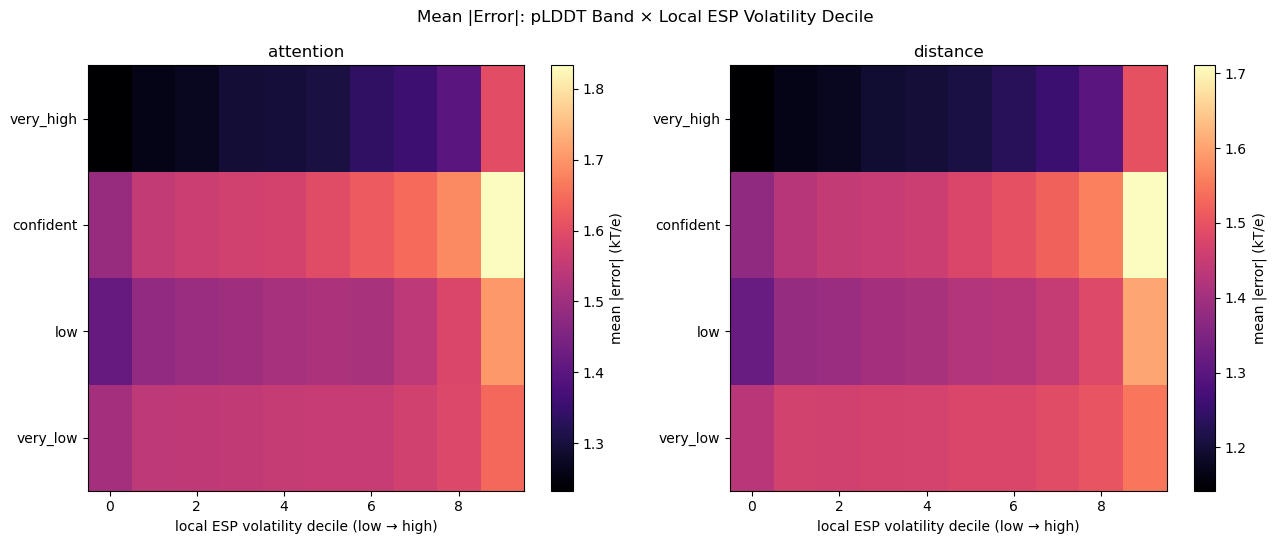

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, model in zip(axes, MODELS):
    sub = dataset[dataset.model == model].copy()
    sub["plddt_band"] = pd.cut(sub["plddt"], bins=[0, 50, 70, 90, 101],
                                labels=PLDDT_BAND_ORDER, right=False)
    sub["local_decile"] = pd.qcut(sub["local_esp_std"], 10, labels=False, duplicates="drop")
    pivot = sub.pivot_table(index="plddt_band", columns="local_decile",
                             values="abs_error", aggfunc="mean", observed=False)
    im = ax.imshow(pivot.to_numpy(), aspect="auto", cmap="magma", origin="lower")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("local ESP volatility decile (low \u2192 high)")
    ax.set_title(model)
    plt.colorbar(im, ax=ax, label="mean |error| (kT/e)")
plt.suptitle("Mean |Error|: pLDDT Band \u00d7 Local ESP Volatility Decile")
plt.tight_layout()
plt.show()

---
## 6. Notes & Findings

**Updated 2026-09-21** — re-run against the slim-graph-retrained champions (see intro). Every number below shifted by less than 0.01 from the pre-retraining run and every qualitative conclusion is unchanged; the underlying relationship between AlphaFold confidence, local ESP physics, and model error is a property of the task, not sensitive to this round of retraining.

**Coverage is complete**: all 5,764,920 query-vertex rows across all 848 test proteins × 2 models joined successfully — 100% PAE coverage, zero out-of-range residue drops.

**Headline result: none of these signals explain much of the error, and pooled correlations are misleading on their own.**

| Predictor | Pooled Spearman r (all vertices) | Median per-protein Spearman r |
|---|---|---|
| pLDDT | −0.094 (attn) / −0.101 (dist) | **+0.011** (attn) / **+0.013** (dist) |
| PAE | +0.120 (attn) / +0.134 (dist) | **−0.057** (attn) / **−0.063** (dist) |
| local ESP volatility | +0.038 (attn) / +0.038 (dist) | +0.058 (attn) / +0.061 (dist) |

pLDDT and PAE both show a "reasonable-looking" pooled correlation (in the expected direction: lower confidence → higher error) — but that correlation **collapses to essentially zero, or even reverses sign, when measured within each protein** (per-protein median r). This is a between-protein (ecological) effect, not a within-protein spatial one: proteins with generally lower average pLDDT/PAE tend to also have different average error for other reasons (most likely size, per `error_clustering_analysis.ipynb`'s dominant finding), and pooling across all vertices conflates that with an apparent per-vertex relationship that isn't really there. **Practical implication: you cannot point to a specific low-pLDDT patch within a protein and expect the model to be worse there.**

**Local ESP volatility is the one predictor that's internally consistent** — pooled and per-protein-median correlations agree in sign and are both weakly positive (~0.04–0.06 for both). This is a real, if small, signal: regions where the ground-truth ESP field itself is locally more volatile *are* modestly harder to predict, independent of AlphaFold confidence — a genuine (if minor) instance of the "hard to predict because the physics is unstable here" hypothesis, not an AF-confidence artifact.

**The pLDDT confidence-band breakdown is not monotonic** (Section 2): only the top band (pLDDT ≥ 90, "very high") shows a clear error reduction (attention: 1.347 vs. 1.521–1.619 kT/e in the other three bands; distance: 1.249 vs. 1.422–1.496). Below that top band, AlphaFold's confidence tiers don't discriminate error at all — "confident" (70–90) is actually the *worst* band for both models, not the "low" band, underscoring that this isn't a smooth confidence-error relationship.

**The two-predictor regression confirms both signals are weak and largely independent, but jointly negligible**: R² tops out at 0.0086 (attention) / 0.0100 (distance) combining pLDDT + local ESP volatility — over 99% of per-vertex error variance is unexplained by either. Standardized coefficients (plddt ≈ −0.09, local_esp_std ≈ +0.10 for both models) show the two do carry some independent information (combined R² ≈ sum of individual R²s, little overlap), but neither is close to a meaningful predictor on its own.

**Consistent between architectures**: attention and distance show the same qualitative pattern throughout (weak pooled correlations, near-zero-to-reversed per-protein correlations for pLDDT/PAE, small positive per-protein correlation for local ESP volatility, non-monotonic pLDDT bands, tiny combined R²) — this is a property of the *task*, not the architecture, matching `error_clustering_analysis.ipynb`'s finding that the two models fail on the same proteins for the same reasons.

**Bottom line for the writeup**: AlphaFold's own structural confidence (pLDDT, PAE) does **not** meaningfully predict where the ESP model goes wrong at the individual-vertex level, despite a superficially plausible pooled correlation that turns out to be a between-protein confound. Local ESP field volatility is a real but small independent contributor. Combined, these AF-uncertainty and local-physics signals explain under 1% of prediction error variance — whatever drives per-vertex error, it is not well captured by AlphaFold's own confidence estimates or local field instability alone. This finding is robust to the graph-format/retraining change — it held before and holds after, essentially unchanged.